In [2]:
masked_interval_starts = [1000, 2000]
masked_interval_ends = [1700, 2900]
mask_windows = list(
    zip(masked_interval_starts, masked_interval_ends)
)
mask_windows

[(1000, 1700), (2000, 2900)]

In [4]:
mask_windows[0]

(1000, 1700)

In [5]:
mask_windows[1]

(2000, 2900)

In [6]:
mask_windows[0][0]

1000

In [7]:
mask_windows[0][1]

1700

In [11]:
from pathlib import Path
from etils import epath

maindir = Path('/home/dpoteryayev/SpectraFormer/notebook.ipynb').parent.resolve()

datadir = maindir / "data"

mixdir = datadir / "mixtures"
mixdir.mkdir(parents=True, exist_ok=True)

unmixdir = mixdir / "unmixed"
unmixdir.mkdir(parents=True, exist_ok=True)

In [20]:
for elem in epath.Path(mixdir).iterdir():
    
    print(elem.parts[-1])

10_1_1buffer4_18x18.nc
551buffer2_11x11.nc
5101buffer3_18x18.nc
5101buffer4_18x18.nc
SiC_19x10x3.nc
10_1_1buffer3_18x18.nc
5101buffer1_18x18.nc
SiC_100x10.nc
unmixed
5101buffer2_18x18.nc
SiC+Graphene_50x20.nc
SiC+Graphene_8x8.nc
551buffer3_15x15.nc
10_1_1buffer1_18x18.nc
551buffer4_15x15.nc
10_1_1buffer2_18x18.nc
551buffer1_11x11.nc


In [23]:
for elem in Path(mixdir).iterdir():
    print(elem, elem.parts[-1])
    print()

/home/dpoteryayev/SpectraFormer/data/mixtures/10_1_1buffer4_18x18.nc 10_1_1buffer4_18x18.nc

/home/dpoteryayev/SpectraFormer/data/mixtures/551buffer2_11x11.nc 551buffer2_11x11.nc

/home/dpoteryayev/SpectraFormer/data/mixtures/5101buffer3_18x18.nc 5101buffer3_18x18.nc

/home/dpoteryayev/SpectraFormer/data/mixtures/5101buffer4_18x18.nc 5101buffer4_18x18.nc

/home/dpoteryayev/SpectraFormer/data/mixtures/SiC_19x10x3.nc SiC_19x10x3.nc

/home/dpoteryayev/SpectraFormer/data/mixtures/10_1_1buffer3_18x18.nc 10_1_1buffer3_18x18.nc

/home/dpoteryayev/SpectraFormer/data/mixtures/5101buffer1_18x18.nc 5101buffer1_18x18.nc

/home/dpoteryayev/SpectraFormer/data/mixtures/SiC_100x10.nc SiC_100x10.nc

/home/dpoteryayev/SpectraFormer/data/mixtures/5101buffer2_18x18.nc 5101buffer2_18x18.nc

/home/dpoteryayev/SpectraFormer/data/mixtures/SiC+Graphene_50x20.nc SiC+Graphene_50x20.nc

/home/dpoteryayev/SpectraFormer/data/mixtures/SiC+Graphene_8x8.nc SiC+Graphene_8x8.nc

/home/dpoteryayev/SpectraFormer/data/mixt

In [2]:
import xarray as xr
import matplotlib.pyplot as plt

In [3]:
unmixed_ds = xr.load_dataset("data/unmixed/unmixed_by_min23_CorrGamma_10_1_1buffer1_18x18.nc")
unmixed_ds['wave_number'] = unmixed_ds['wave_number'] * 800 + 2000
unmixed_ds

<xarray.Dataset>
Dimensions:               (sample: 264, wave_number: 1015)
Coordinates:
  * sample                (sample) int64 0 1 2 3 4 5 ... 258 259 260 261 262 263
  * wave_number           (wave_number) float32 1.278e+03 1.28e+03 ... 2.82e+03
Data variables:
    spectra               (sample, wave_number) float32 0.2179 0.2179 ... 0.1632
    masked_spectra        (sample, wave_number) float32 -1.0 -1.0 ... -1.0 -1.0
    mask                  (sample, wave_number) bool False False ... False False
    predicted_spectra     (sample, wave_number) float32 0.1853 0.1857 ... 0.1826
    predicted_difference  (sample, wave_number) float32 0.03258 ... -0.01938

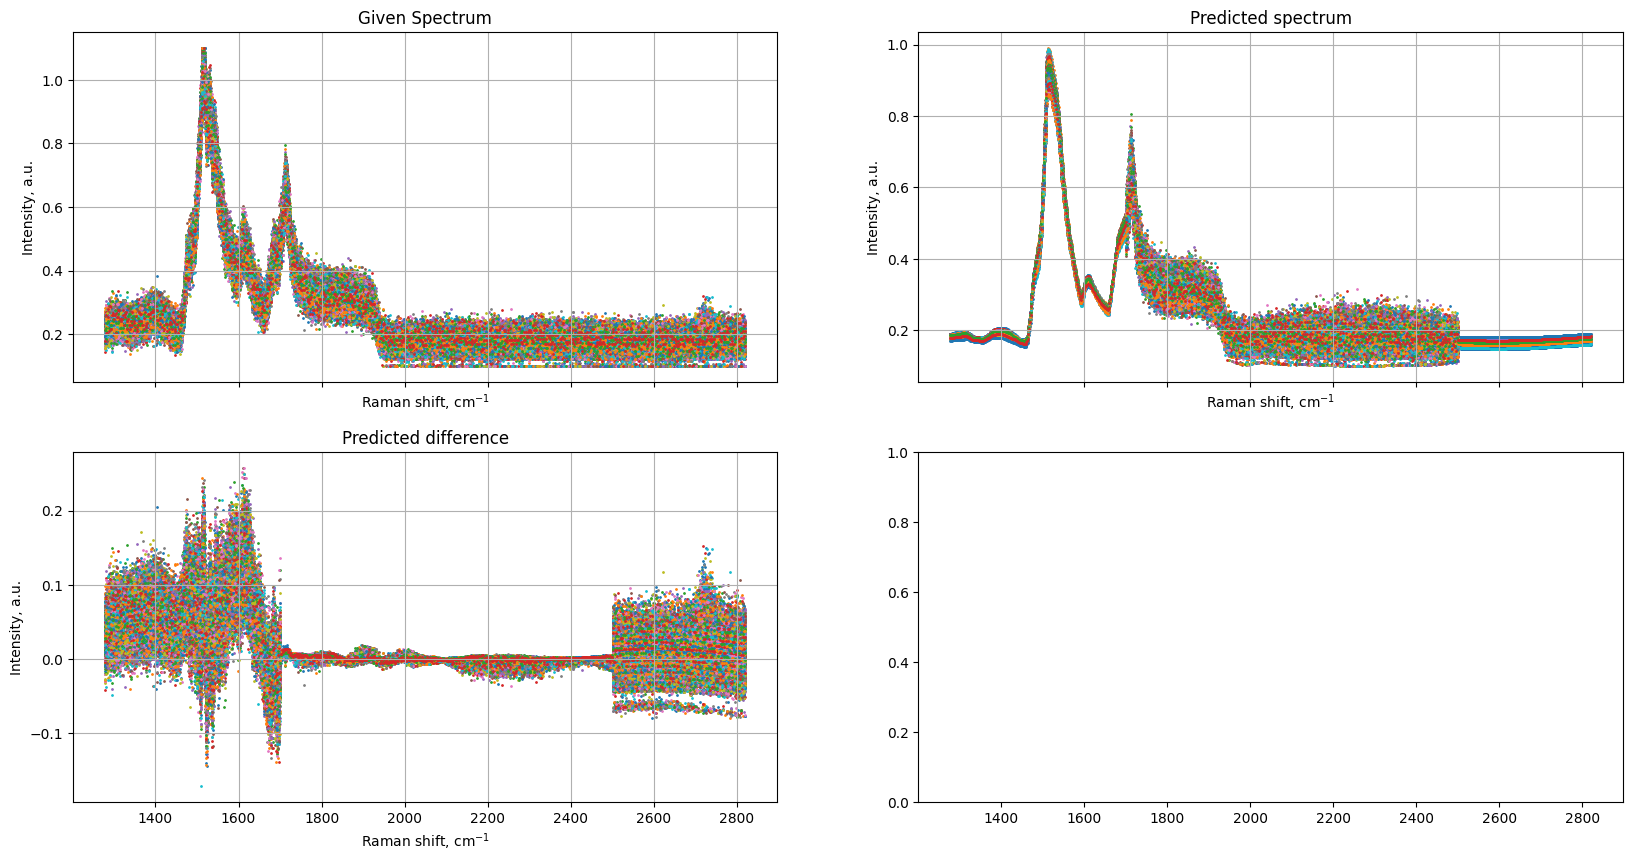

In [6]:
fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 2, sharex=True)

for i in range(len(unmixed_ds['sample'])):

    axes[0,0].scatter(x=unmixed_ds['wave_number'], y=unmixed_ds['spectra'][i], s=1)
    axes[0,0].set_xlabel('Raman shift, cm$^{-1}$')
    axes[0,0].set_ylabel('Intensity, a.u.')
    axes[0,0].set_title('Given Spectrum')
    axes[0,0].grid(visible=True, which='major', axis='both')

    axes[0,1].scatter(x=unmixed_ds['wave_number'], y=unmixed_ds['predicted_spectra'][i], s=1)
    axes[0,1].set_xlabel('Raman shift, cm$^{-1}$')
    axes[0,1].set_ylabel('Intensity, a.u.')
    axes[0,1].set_title('Predicted spectrum')
    axes[0,1].grid(visible=True, which='major', axis='both')

    axes[1,0].scatter(x=unmixed_ds['wave_number'], y=unmixed_ds['predicted_difference'][i], s=1)
    axes[1,0].set_xlabel('Raman shift, cm$^{-1}$')
    axes[1,0].set_ylabel('Intensity, a.u.')
    axes[1,0].set_title('Predicted difference')
    axes[1,0].grid(visible=True, which='major', axis='both')

plt.show()